# Receive-field shading

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrutils/blob/main/examples/bias_field.ipynb)

`bias_field_correct`: N4 correction for the smooth multiplicative shading a
surface array leaves behind. Needs the `bias` extra.

In [1]:
try:
    import mrutils  # noqa: F401
except ImportError:
    %pip install -q "mrutils[bias]" matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mrutils as mru

n = 128
y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]

# Three tissue classes and air. N4 separates shading from anatomy by sharpening
# the intensity histogram, so what it needs of an object is that it has classes.
truth = np.zeros((n, n))
truth[((x / 0.72) ** 2 + (y / 0.92) ** 2) <= 1] = 0.55
truth[((x / 0.66) ** 2 + (y / 0.86) ** 2) <= 1] = 0.85
truth[(((x - 0.16) / 0.10) ** 2 + (y / 0.30) ** 2 <= 1)
      | (((x + 0.16) / 0.10) ** 2 + (y / 0.30) ** 2 <= 1)] = 0.25
support = truth > 0.0

# The shading a surface array leaves: smooth, multiplicative, brightest where
# the elements are.
field = 0.55 + 1.1 * np.exp(-((x - 0.55) ** 2 + (y + 0.35) ** 2) / 0.9)
field /= field.mean()

rng = np.random.default_rng(0)
observed = (truth * field + 0.01 * rng.normal(size=truth.shape)).astype(np.float32)
print(f"the field spans {field.min():.2f} to {field.max():.2f} of its mean")

the field spans 0.55 to 1.63 of its mean


## Correcting it

A surface array sees the object through a sensitivity that falls away with
distance, so a uniform tissue comes back bright near the coils and dim in the
middle. The shading is smooth and multiplicative, which is what lets it be
separated from anatomy at all: N4 estimates it as a B-spline field by
sharpening the log-intensity histogram, and dividing it out leaves the
anatomy.

The measure below is the spread over one tissue class. It is zero in the
object, so whatever it reads is shading.

In [3]:
corrected, estimated = mru.bias_field_correct(observed, return_field=True)

brightest = truth > 0.8


def uniformity(image):
    """Spread over one tissue class, which is zero unless something shades it."""
    return float(image[brightest].std() / image[brightest].mean())


print(f"uniformity: {uniformity(observed):.3f} observed -> "
      f"{uniformity(corrected):.3f} corrected   (the object itself: "
      f"{uniformity(truth):.3f})")

# A multiplicative field is only defined up to a constant -- the constant goes
# into the image -- so it is compared after matching the mean over the object.
scale = field[support].mean() / estimated[support].mean()
residual = np.abs(scale * estimated - field)[support] / field[support]
print(f"field recovered to {100 * np.median(residual):.1f}% (median, inside the object)")

uniformity: 0.260 observed -> 0.015 corrected   (the object itself: 0.000)
field recovered to 0.8% (median, inside the object)


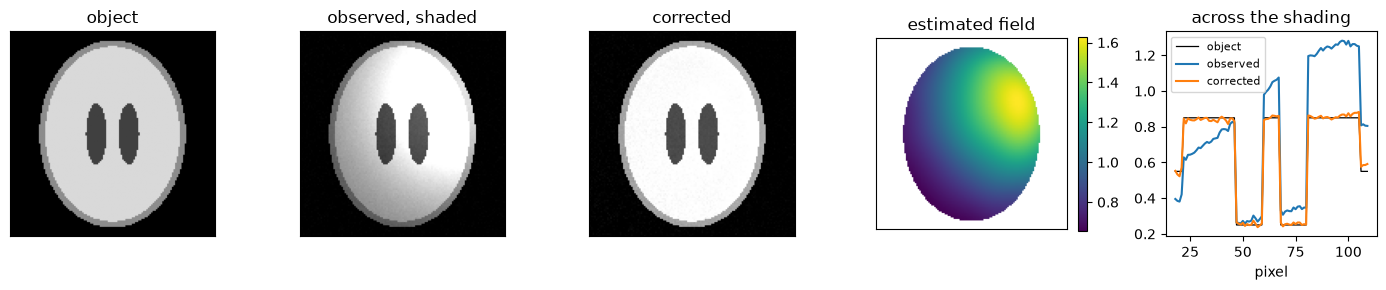

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3.0))
for axis, data, title in (
    (axes[0], truth, "object"),
    (axes[1], observed, "observed, shaded"),
    (axes[2], corrected, "corrected"),
):
    axis.imshow(data, cmap="gray", vmin=0, vmax=1.0)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])

shown = axes[3].imshow(np.where(support, scale * estimated, np.nan), cmap="viridis")
axes[3].set_title("estimated field")
axes[3].set_xticks([])
axes[3].set_yticks([])
fig.colorbar(shown, ax=axes[3], fraction=0.046)

# The correction removes the field's shape but not its constant, so the
# profile is drawn against the object with that constant matched.
row = n // 2
level = truth[brightest].mean() / corrected[brightest].mean()
inside = lambda values: np.where(support[row], values[row], np.nan)
axes[4].plot(inside(truth), color="k", linewidth=0.9, label="object")
axes[4].plot(inside(observed), label="observed")
axes[4].plot(inside(level * corrected), label="corrected")
axes[4].set_title("across the shading")
axes[4].set_xlabel("pixel")
axes[4].legend(fontsize=8)
fig.tight_layout()

In [5]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "bias_field.png", dpi=110, bbox_inches="tight")

## The mask, and the grid it is fitted on

Two knobs decide what this costs and whether it works at all, and both are
worth seeing rather than trusting.

It is an image-domain correction applied after coil combination. It is not a
substitute for sensitivity maps in a SENSE solve, which is where the same
physics is handled quantitatively — and being blind to what caused the
shading, it will flatten a real intensity gradient just as happily.

In [6]:
# The default thresholds the image with Otsu's method. The mask is not a
# formality: N4 fits the field only where the mask says there is signal, so
# handing it the object's full extent -- dim boundary rim included -- fits the
# field partly to the roll-off at the edge, and does worse than the threshold.
explicit = mru.bias_field_correct(observed, mask=support.astype(np.uint8))
print(f"Otsu, the default: {uniformity(corrected):.3f}")
print(f"the full support:  {uniformity(explicit):.3f}")

# The field is fitted on a grid coarsened by shrink_factor and evaluated back
# at full resolution, because it is smooth by construction. Coarsening too far
# stops resolving it.
for shrink in (1, 4, 8):
    estimate = mru.bias_field_correct(observed, shrink_factor=shrink)
    print(f"shrink_factor={shrink}: {uniformity(estimate):.3f}")

volume = np.stack([observed * weight for weight in np.linspace(0.9, 1.1, 8)])
print(f"3D works the same way: {mru.bias_field_correct(volume).shape}")

Otsu, the default: 0.015
the full support:  0.359


shrink_factor=1: 0.029


shrink_factor=4: 0.015


shrink_factor=8: 0.049


3D works the same way: (8, 128, 128)
